# 03 EDA

In [10]:
import pandas as pd

df_clean = pd.read_csv("C:\\Users\\Siddhesh\\Downloads\\Projects\\E-commerce\\ecommerce-sales-customer-intelligence\\data\\retail_clean.csv")

print(df_clean.shape)
df_clean.head()

(19469, 13)


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Revenue,Year,Month,YearMonth,IsCancelled
0,555150,22762,CUPBOARD 3 DRAWER MA CAMPAGNE,1,2011-05-31 15:53:00,29.17,NaN,United Kingdom,29.17,2011,5,2011-05,False
1,575477,22645,CERAMIC HEART FAIRY CAKE MONEY BANK,1,2011-11-09 16:14:00,3.29,NaN,United Kingdom,3.29,2011,11,2011-11,False
2,538177,84596E,SMALL LICORICE DES PINK BOWL,1,2010-12-10 09:51:00,2.51,NaN,United Kingdom,2.51,2010,12,2010-12,False
3,575930,23378,PACK OF 12 50'S CHRISTMAS TISSUES,1,2011-11-11 17:58:00,0.83,NaN,United Kingdom,0.83,2011,11,2011-11,False
4,546890,22084,PAPER CHAIN KIT EMPIRE,6,2011-03-17 18:18:00,2.95,13394.0,United Kingdom,17.70,2011,3,2011-03,False


In [11]:
import matplotlib.pyplot as plt
import seaborn as sns

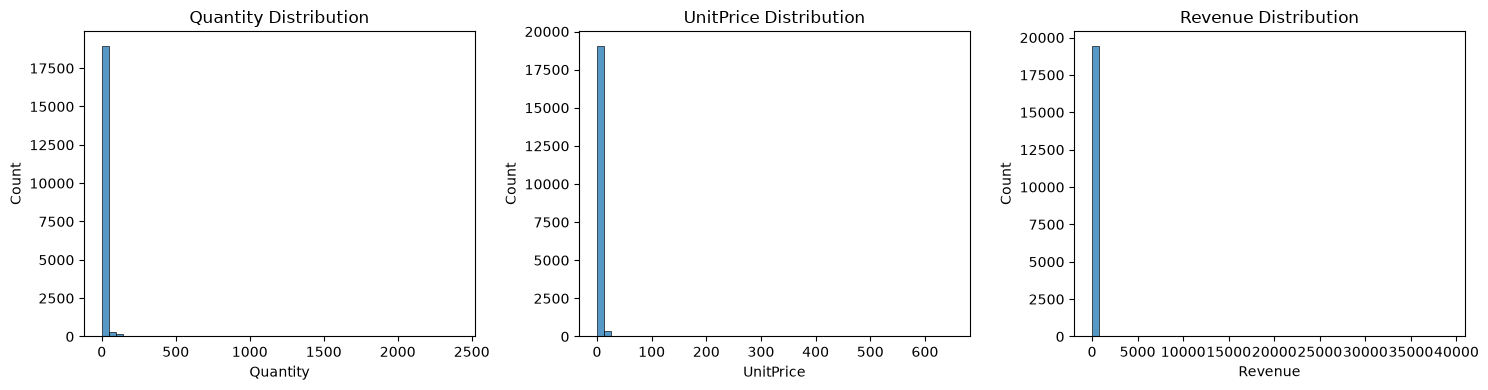

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(15,4))
sns.histplot(df_clean['Quantity'], bins=50, ax=axes[0]).set(title='Quantity Distribution')
sns.histplot(df_clean['UnitPrice'], bins=50, ax=axes[1]).set(title='UnitPrice Distribution')
sns.histplot(df_clean['Revenue'], bins=50, ax=axes[2]).set(title='Revenue Distribution')
plt.tight_layout(); plt.show()

1. Quantity Distribution -
The quantity distribution is highly right-skewed. Most transactions involve small quantities, while a small number of bulk transactions create extreme high values.
2. UnitPrice Distribution -
Unit price is highly concentrated at the lower end, with a few expensive products creating a long right tail.
3. Revenue Distribution -
Revenue is highly right-skewed, with most transactions generating relatively low revenue and a small number of high-value transactions contributing disproportionately large amounts.

# Bivariate

<Axes: ylabel='Country'>

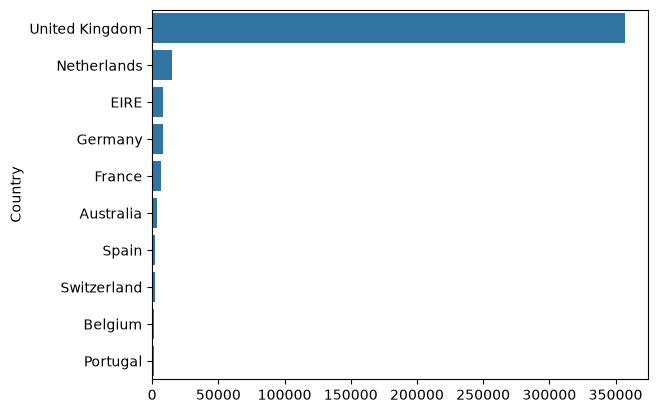

In [14]:
# Revenue by country
top_countries = df_clean.groupby('Country')['Revenue'].sum().sort_values(ascending=False).head(10)
sns.barplot(x=top_countries.values, y=top_countries.index)


The United Kingdom generates the majority of total revenue by a large margin. The Netherlands is the second-highest contributor, but its revenue is considerably lower than the UK. Other countries such as EIRE, Germany, France, Australia, Spain, Switzerland, Belgium, and Portugal contribute relatively small portions of total revenue. This indicates that the business is highly concentrated in the UK market within this dataset.

<Axes: title={'center': 'Monthly Revenue Trend'}, xlabel='YearMonth'>

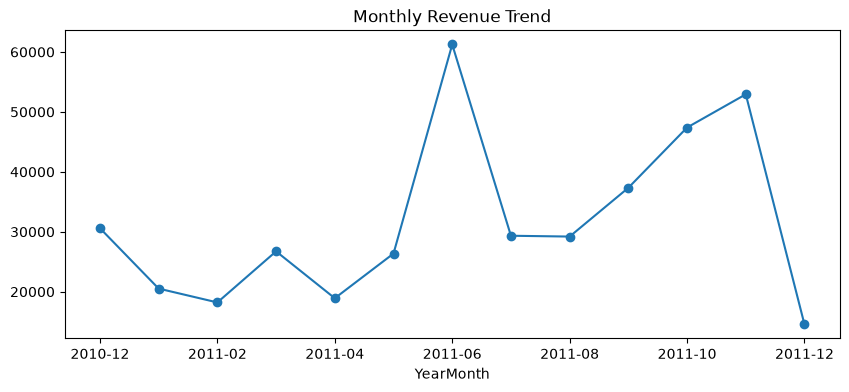

In [22]:
# Revenue vs month
monthly = df_clean.groupby('YearMonth')['Revenue'].sum()
monthly.plot(kind='line', marker='o', figsize=(10,4), title='Monthly Revenue Trend')

Monthly revenue fluctuates considerably throughout the period. Revenue reaches its highest level in June 2011 at approximately 61K. After declining in July and August, revenue increases steadily from September through November, reaching approximately 53K in November. December shows a sharp decline to approximately 14K; however, this should be interpreted cautiously because the dataset ends early in December.

<Axes: xlabel='Quantity', ylabel='Revenue'>

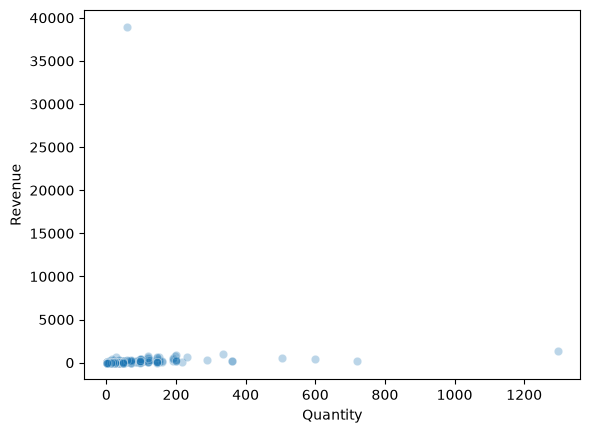

In [23]:
# Quantity vs Revenue scatter (sampled, since 400k+ points will overplot)
sample = df_clean.sample(5000, random_state=42)
sns.scatterplot(data=sample, x='Quantity', y='Revenue', alpha=0.3)

The scatter plot shows that most transactions have relatively low quantities and revenue. A small number of extreme observations create significant outliers, including one transaction with revenue close to 39K. High quantities do not consistently correspond to high revenue, indicating that revenue depends not only on quantity but also on the unit price of the products.

# Time series

In [19]:
df_clean['InvoiceDate'] = pd.to_datetime(df_clean['InvoiceDate'])
df_clean['InvoiceDate'].dtype

dtype('<M8[us]')

<Axes: title={'center': 'Weekly Revenue'}, xlabel='InvoiceDate'>

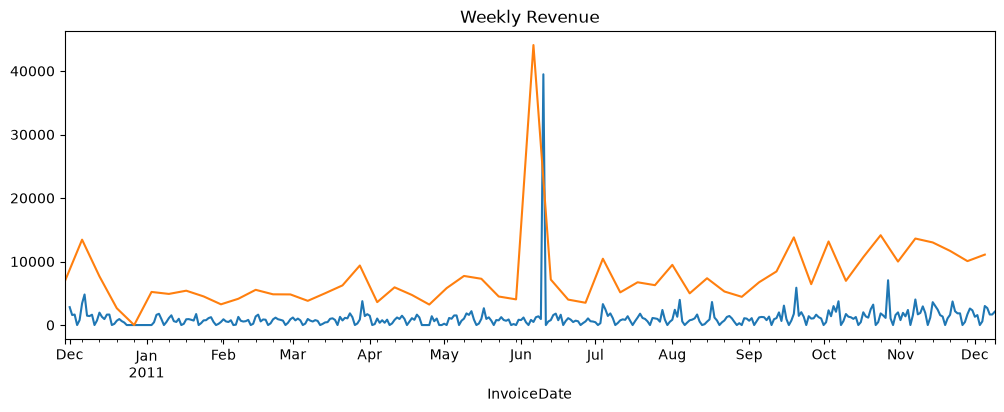

In [20]:
daily = df_clean.set_index('InvoiceDate').resample('D')['Revenue'].sum()
weekly = df_clean.set_index('InvoiceDate').resample('W')['Revenue'].sum()
daily.plot(figsize=(12,4), title='Daily Revenue')
weekly.plot(figsize=(12,4), title='Weekly Revenue')

The weekly revenue shows significant fluctuations throughout the year rather than a consistent seasonal pattern. There is a very large revenue spike around early June 2011, while several smaller peaks occur around September, October, and November. Revenue remains relatively lower during parts of January, February, March, and the summer months. December shows a decline toward the end of the dataset, but this should be interpreted cautiously because the dataset ends in early December.